In [85]:
# Import core libraries for simulation and analysis
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(100)

In [86]:
# Number of lots entering the system (simulation scale)
num_lots = 3000

# Semiconductor manufacturing process flow
process_flow = ["Litho", "Etch", "Clean", "Test"]

# Machine processing characteristics (mean = central tendency, std = variability)
machines = {
    "Litho": {"mean": 10, "std": 2},
    "Etch": {"mean": 15, "std": 3},
    "Clean": {"mean": 8, "std": 1},
    "Test": {"mean": 5, "std": 1}
}

In [87]:
# Generate synthetic wafer lots entering the fab system
# Each lot represents a work unit flowing through the semiconductor process

lots = pd.DataFrame({
    "lot_id": [f"L{i}" for i in range(num_lots)],

    # Arrival process modeled using exponential distribution
    # This simulates random job arrivals in a manufacturing system
    "arrival_time": np.random.exponential(scale=5, size=num_lots).cumsum()
})

# Preview generated dataset
lots.head()

,lot_id,arrival_time
0,L0,3.919792
1,L1,5.551001
2,L2,8.313734
3,L3,17.628169
4,L4,17.651819


In [88]:
# Simulate each lot going through the semiconductor process flow
# This calculates cycle time based on stochastic processing times

cycle_times = []

for i in range(num_lots):
    
    total_process_time = 0

    # Each lot goes through all process steps sequentially
    for step in process_flow:
        
        # Get machine parameters for current step
        params = machines[step]

        # Sample processing time using normal distribution
        # This introduces variability (realistic manufacturing behavior)
        process_time = np.random.normal(params["mean"], params["std"])

        # Ensure no negative processing time
        process_time = max(0, process_time)

        total_process_time += process_time

    cycle_times.append(total_process_time)

# Add results to dataframe
lots["cycle_time"] = cycle_times

# Preview result
lots.head()

,lot_id,arrival_time,cycle_time
0,L0,3.919792,33.456311
1,L1,5.551001,42.547820
2,L2,8.313734,37.307233
3,L3,17.628169,37.792885
4,L4,17.651819,39.590534


In [89]:
# Basic statistical summary of cycle time

print("Cycle Time Statistics (basic view)")
print(lots["cycle_time"].describe())

Cycle Time Statistics (basic view)
count    3000.000000
mean       38.011267
std         3.842893
min        24.982337
25%        35.336825
50%        37.961919
75%        40.575383
max        51.639759
Name: cycle_time, dtype: float64


In [90]:
# Variability metric (important for planning risk)

cv = lots["cycle_time"].std() / lots["cycle_time"].mean()

print(f"Cycle Time CV (variability): {cv:.3f}")

Cycle Time CV (variability): 0.101


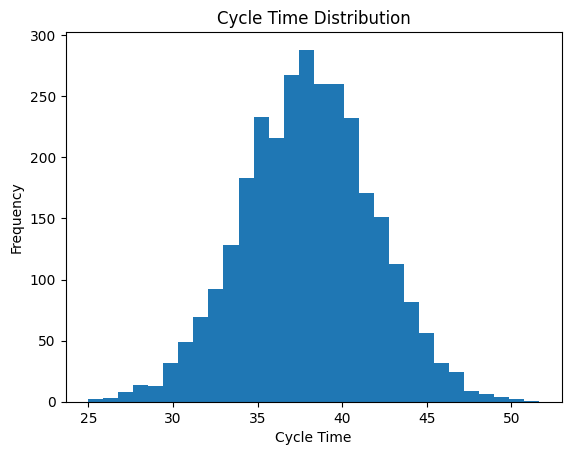

In [94]:
# Distribution of cycle time

plt.hist(lots["cycle_time"], bins=30)
plt.title("Cycle Time Distribution")
plt.xlabel("Cycle Time")
plt.ylabel("Frequency")
plt.show()

In [95]:
# Planning-level risk metrics (tail-based planning)

p90 = np.percentile(lots["cycle_time"], 90)
p95 = np.percentile(lots["cycle_time"], 95)

mean_ct = lots["cycle_time"].mean()

print(f"Mean Cycle Time: {mean_ct:.2f}")
print(f"P90 Cycle Time: {p90:.2f}")
print(f"P95 Cycle Time: {p95:.2f}")

Mean Cycle Time: 38.01
P90 Cycle Time: 42.94
P95 Cycle Time: 44.29


In [96]:
# Variability buffer (how much extra time needed beyond average)

p90_buffer = p90 - mean_ct
p95_buffer = p95 - mean_ct

print(f"P90 Buffer (vs mean): {p90_buffer:.2f}")
print(f"P95 Buffer (vs mean): {p95_buffer:.2f}")

P90 Buffer (vs mean): 4.93
P95 Buffer (vs mean): 6.28


In [97]:
# Sensitivity analysis: increase process variability
# Test how cycle time changes when machine variability increases by 50%

cycle_times_high_var = []

for i in range(num_lots):
    
    total_process_time = 0

    for step in process_flow:
        
        params = machines[step]

        # Increase variability by 50%
        process_time = np.random.normal(
            params["mean"], 
            params["std"] * 1.5
        )

        process_time = max(0, process_time)
        total_process_time += process_time

    cycle_times_high_var.append(total_process_time)

# Add to dataframe
lots["cycle_time_high_var"] = cycle_times_high_var

In [98]:
# Compare baseline vs high variability

print("Baseline Mean:", round(lots["cycle_time"].mean(), 2))
print("High Variability Mean:", round(lots["cycle_time_high_var"].mean(), 2))

print("Baseline P90:", round(np.percentile(lots["cycle_time"], 90), 2))
print("High Variability P90:", round(np.percentile(lots["cycle_time_high_var"], 90), 2))

Baseline Mean: 38.01
High Variability Mean: 37.97
Baseline P90: 42.94
High Variability P90: 45.25


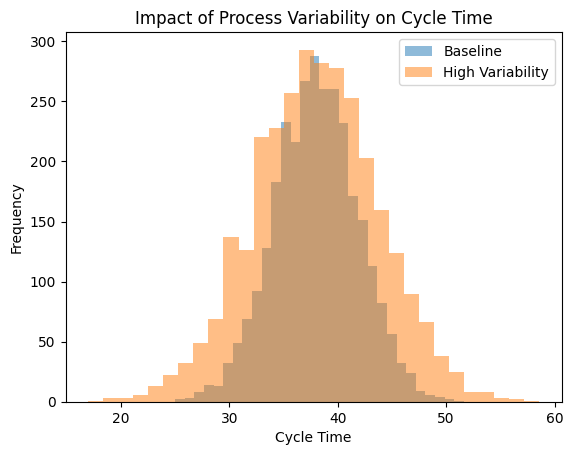

In [99]:
plt.hist(lots["cycle_time"], bins=30, alpha=0.5, label="Baseline")
plt.hist(lots["cycle_time_high_var"], bins=30, alpha=0.5, label="High Variability")
plt.title("Impact of Process Variability on Cycle Time")
plt.xlabel("Cycle Time")
plt.ylabel("Frequency")
plt.legend()
plt.show()

In [100]:
import pandas as pd

summary = pd.DataFrame({
    "Scenario": ["Baseline", "High Variability"],
    "Mean Cycle Time": [
        round(lots["cycle_time"].mean(), 2),
        round(lots["cycle_time_high_var"].mean(), 2)
    ],
    "P90 Cycle Time": [
        round(np.percentile(lots["cycle_time"], 90), 2),
        round(np.percentile(lots["cycle_time_high_var"], 90), 2)
    ],
    "P95 Cycle Time": [
        round(np.percentile(lots["cycle_time"], 95), 2),
        round(np.percentile(lots["cycle_time_high_var"], 95), 2)
    ]
})

summary

,Scenario,Mean Cycle Time,P90 Cycle Time,P95 Cycle Time
0,Baseline,38.01,42.94,44.29
1,High Variability,37.97,45.25,47.50


In [101]:
print("""
Key Insights:

1. Mean cycle time remains stable under increased variability.
2. P90 cycle time increases significantly under higher variability.
3. System risk is driven by variability, not average performance.
4. Planning decisions should be based on tail metrics (P90/P95), not mean.
""")


Key Insights:

1. Mean cycle time remains stable under increased variability.
2. P90 cycle time increases significantly under higher variability.
3. System risk is driven by variability, not average performance.
4. Planning decisions should be based on tail metrics (P90/P95), not mean.



In [102]:
print("""
Engineering Interpretation:

This simulation shows that semiconductor manufacturing systems are highly sensitive to process variability.
Even if average performance remains unchanged, delivery risk increases significantly.

Therefore, capacity planning should include variability buffers based on P90/P95 metrics rather than relying on mean cycle time.
""")


Engineering Interpretation:

This simulation shows that semiconductor manufacturing systems are highly sensitive to process variability.
Even if average performance remains unchanged, delivery risk increases significantly.

Therefore, capacity planning should include variability buffers based on P90/P95 metrics rather than relying on mean cycle time.

